# Carrefour Customer Segmentation — MVP Pipeline

This notebook implements an end-to-end behavioral segmentation pipeline over **191 million purchase transactions** from 1.48 million Carrefour customers across 6 months (Jan–Jun 2022). The goal is to discover **organic customer tribes** — groups defined purely by what people buy and how they shop, with no demographic profiling.

## Pipeline Overview

| Phase | Step | Method |
|---|---|---|
| 0 | Data validation & EDA | Polars lazy frames, quality gates |
| 1 | Product embeddings | Word2Vec / Item2Vec (cart = sentence, product = word) |
| 2 | Customer vectors | Frequency-weighted + time-decay aggregation |
| 3 | Dimensionality reduction | UMAP (primary) vs PCA (baseline) |
| 4 | Clustering | HDBSCAN (primary) vs K-Means (baseline) |


## Section 0 — Setup & Imports

In [2]:
# Section 0 — Setup & Imports
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

from src.config import DATA_PROCESSED, OUTPUTS, SAMPLE_SIZE
from src.data_loader import load_maestra_articulos, load_linea_tickets

OUTPUTS.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
print("imports OK")

imports OK


## Section 1 — Data Inventory

Before any modelling, we establish what we are actually working with. Two source files feed the pipeline:

- **`ie_maestra_articulos`** — the product master: ~894k SKU rows mapping each `idarticu` to a human-readable name and sector label. This is the reference table that will enrich every transaction with categorical context.
- **`ie_linea_ticket`** — the transactional backbone: every individual line item purchased across all stores and the full 6-month window. At 191M rows this is the primary modelling dataset.

The goal here is to confirm the data matches the project brief (1.48M customers, 191M rows, Jan–Jun 2022, 4 stores) and surface any immediate structural anomalies before we invest compute on quality checks and feature engineering.

In [3]:
# product master — ~893k product SKUs with sector labels
df_articles = load_maestra_articulos()

print(f"Shape: {df_articles.shape[0]:,} rows × {df_articles.shape[1]} cols")
print(f"Columns: {df_articles.columns}")

print("\nProducts per sector:")
print(
    df_articles.group_by(["idsector", "desc_sector"])
               .agg(pl.len().alias("n_products"))
               .sort("n_products", descending=True)
)
df_articles.head()

Shape: 893,944 rows × 4 cols
Columns: ['idarticu', 'desc_larga_articulo', 'idsector', 'desc_sector']

Products per sector:
shape: (6, 3)
┌──────────┬──────────────────────┬────────────┐
│ idsector ┆ desc_sector          ┆ n_products │
│ ---      ┆ ---                  ┆ ---        │
│ i64      ┆ str                  ┆ u32        │
╞══════════╪══════════════════════╪════════════╡
│ 3        ┆ BAZAR                ┆ 425050     │
│ 1        ┆ P.G.C.               ┆ 171672     │
│ 6        ┆ TEXTIL               ┆ 132735     │
│ 2        ┆ PROD. FRESCOS TRADIC ┆ 88033      │
│ 4        ┆ ELECTROFOTO          ┆ 75979      │
│ 7        ┆ GASOLINERA           ┆ 475        │
└──────────┴──────────────────────┴────────────┘


idarticu,desc_larga_articulo,idsector,desc_sector
i64,str,i64,str
966557,"""GUISO DE VERDURAS LITORAL 415 …",1,"""P.G.C."""
909163,"""LA HISTORIA DE LOS 3 CERDITOS …",3,"""BAZAR"""
594029,"""MUU (SUSAETA)""",3,"""BAZAR"""
86412,"""ALAS DE MOSCA PARA ÃNGEL ANAY…",3,"""BAZAR"""
507503,"""CAMISETA NINO MANGA LARGA SPID…",6,"""TEXTIL"""


In [4]:
# transaction lines — lazy frame over the full 191M-row dataset (never fully materialised)
df_tickets = load_linea_tickets()

scan = df_tickets.select([
    pl.len().alias("n_rows"),
    pl.col("cliente").n_unique().alias("n_customers"),
    pl.col("ticket").n_unique().alias("n_tickets"),
    pl.col("idarticu").n_unique().alias("n_products"),
    pl.col("fecha").min().alias("date_min"),
    pl.col("fecha").max().alias("date_max"),
    pl.col("idempres").n_unique().alias("n_stores"),
]).collect().row(0, named=True)

n_raw = scan["n_rows"]

print(f"Columns: {df_tickets.columns}")
print()
print(f"Total rows: {n_raw:>15,}")
print(f"Unique customers: {scan['n_customers']:>15,}")
print(f"Unique tickets: {scan['n_tickets']:>15,}")
print(f"Unique products: {scan['n_products']:>15,}")
print(f"Date range: {scan['date_min']}  →  {scan['date_max']}")
print(f"Stores: {scan['n_stores']}")
print()

# monthly breakdown with inline bar
monthly_raw = (
    df_tickets.with_columns(pl.col("fecha").dt.strftime("%Y-%m").alias("month"))
              .group_by("month").agg(pl.len().alias("n"))
              .sort("month").collect().to_pandas()
)
print("Monthly transaction volume:")
max_n = monthly_raw["n"].max()
for _, row in monthly_raw.iterrows():
    bar = "█" * int(row["n"] / max_n * 30)
    print(f"  {row['month']}  {row['n']:>12,}  {bar}")

Columns: ['idempres', 'fecha', 'hora', 'ticket', 'cliente', 'idarticu', 'unidades', 'importe', 'idpromoc', 'idtiprod']

Total rows:     191,017,715
Unique customers:       1,482,715
Unique tickets:      20,026,724
Unique products:         117,701
Date range: 2022-01-01  →  2022-06-30
Stores: 4

Monthly transaction volume:
  2022-01    32,296,827  ████████████████████████████
  2022-02    29,521,934  █████████████████████████
  2022-03    34,077,920  ██████████████████████████████
  2022-04    30,614,164  ██████████████████████████
  2022-05    33,162,123  █████████████████████████████
  2022-06    31,344,747  ███████████████████████████


## Section 2 — Data Quality Gates

A segmentation pipeline built on dirty data will produce clusters that reflect data artefacts, not genuine customer behaviour. Before committing to any feature engineering, we run **eight automated checks** as hard gates:

| Check | What it validates |
|---|---|
| Schema validation | Both files have the expected columns and types |
| Null audit | No missing values in either dataset |
| Anomaly audit | Scale of negative/zero quantities and prices; determines the cleaning rule |
| Product coverage | ≥ 90% of ticket product IDs resolve in the master (orphaned products get no embedding) |
| Temporal completeness | All 6 calendar months present, each > 10M transactions |
| Customer activity | Distribution of tickets per customer; confirms enough active customers to cluster |
| Promotional integrity | `idpromoc` category counts and promo rate — a key behavioral axis in Phase 2 |
| Store integrity | Transaction volume and revenue per store |

All checks run regardless of failures so the full picture is visible at once. Results are saved to `data/processed/quality_report.json` for downstream reference.

In [5]:
from src.data_quality import (
    validate_schema, audit_nulls, audit_anomalies,
    check_product_coverage, check_temporal_completeness,
    audit_customer_activity, audit_promotional_data,
    audit_stores, build_quality_report,
)

# run all checks — saves quality_report.json to data/processed/
report = build_quality_report(verbose=True)

  DATA QUALITY REPORT — Carrefour Segmentation Pipeline

[schema_validation]
  articles_columns: ['desc_larga_articulo', 'desc_sector', 'idarticu', 'idsector']
  articles_dtypes: {'idarticu': 'Int64', 'desc_larga_articulo': 'String', 'idsector': 'Int64', 'desc_sector': 'String'}
  articles_shape: [893944, 4]
  ticket_columns: ['cliente', 'fecha', 'hora', 'idarticu', 'idempres'] ... (10 total)
  ticket_dtypes: (10 entries)
  ticket_n_cols: 10
  --> PASS

[null_audit]
  articles_nulls: {'idarticu': 0, 'desc_larga_articulo': 0, 'idsector': 0, 'desc_sector': 0}
  articles_total_nulls: 0
  ticket_null_counts: (10 entries)
  ticket_total_nulls: 0
  --> PASS

[anomaly_audit]
  total_rows: 191017715
  anomaly_counts: {'negative_unidades': 0, 'zero_unidades': 0, 'extreme_unidades_gt1000': 3248, 'negative_importe': 287, 'zero_importe': 654909, 'extreme_importe_gt10k': 53}
  anomaly_pcts: {'negative_unidades': 0.0, 'zero_unidades': 0.0, 'extreme_unidades_gt1000': 0.0017, 'negative_importe': 0.000

In [6]:
# ── Anomaly detail: understand scale of returns / bad data ──────────────────
anom = report["anomaly_audit"]
print(f"Total rows: {anom['total_rows']:>15,}")
print(f"Rows retained: {anom['rows_retained']:>15,}  ({anom['rows_retained_pct']:.2f}%)")
print(f"Rows dropped: {anom['rows_dropped_by_cleaning_rule']:>15,}  ({anom['rows_dropped_pct']:.2f}%)")
print()
print("Anomaly breakdown:")
for k, v in anom["anomaly_counts"].items():
    pct = anom["anomaly_pcts"][k]
    print(f"  {k:<35}: {v:>10,}  ({pct:.3f}%)")
print(f"\nCleaning rule: {anom['cleaning_rule']}")

Total rows:     191,017,715
Rows retained:     190,362,519  (99.66%)
Rows dropped:         655,196  (0.34%)

Anomaly breakdown:
  negative_unidades                  :          0  (0.000%)
  zero_unidades                      :          0  (0.000%)
  extreme_unidades_gt1000            :      3,248  (0.002%)
  negative_importe                   :        287  (0.000%)
  zero_importe                       :    654,909  (0.343%)
  extreme_importe_gt10k              :         53  (0.000%)

Cleaning rule: DROP unidades <= 0 OR importe <= 0


In [7]:
# ── Customer activity: confirm segmentation sample is viable ─────────────────
ca = report["customer_activity"]
print(f"Total unique customers  : {ca['total_unique_customers']:>10,}")
print(f"Eligible (>= {ca['min_tickets_threshold']} tickets)  : {ca['eligible_customers']:>10,}")
print(f"Ineligible              : {ca['ineligible_customers']:>10,}  ({ca['ineligible_pct']:.1f}%)")
print(f"Sample size feasible    : {ca['sample_size_feasible']}  (need 100,000)")
print()
print(f"Tickets per customer — distribution:")
print(f"  p10 = {ca['p10_tickets']:.0f}    p25 = {ca['p25_tickets']:.0f}    "
      f"median = {ca['median_tickets']:.0f}    mean = {ca['mean_tickets']:.1f}")
print(f"  p75 = {ca['p75_tickets']:.0f}    p95 = {ca['p95_tickets']:.0f}    "
      f"p99 = {ca['p99_tickets']:.0f}    max = {ca['max_tickets']:,}")

Total unique customers  :  1,482,715
Eligible (>= 3 tickets)  :  1,086,761
Ineligible              :    395,954  (26.7%)
Sample size feasible    : True  (need 100,000)

Tickets per customer — distribution:
  p10 = 1    p25 = 2    median = 7    mean = 13.5
  p75 = 17    p95 = 49    p99 = 96    max = 1,613


## Section 3 — Merge & Clean

With quality confirmed, we build the single working dataset that all downstream analysis uses. Two operations happen here: **filter** then **join**.

---

### 3.1 Why we drop rows before merging

The cleaning rule is: **`DROP rows where unidades ≤ 0 OR importe ≤ 0`**

Three distinct row types are removed:

| Row type | Condition | Why it must go |
|---|---|---|
| **Returns / voids** | `unidades < 0` | A customer reversing a purchase is **not** expressing purchase intent. If kept, Word2Vec sees "buy beer → return chips" as a co-purchase co-occurrence, teaching the model that beer and chip-returns are semantically similar. This corrupts product embeddings at the foundation of the pipeline. |
| **Credit notes** | `importe < 0` | Financial reversal lines attached to a prior return. Negative spend distorts every Phase 2 customer metric: basket size, 6-month CLV, and promo-sensitivity rate all become unreliable if credit notes inflate the negative tail. |
| **Zero-price lines** | `importe = 0` | System-generated lines for free samples, loyalty scheme allocations, or data-entry corrections. They carry **zero spending signal** — including them would inflate ticket counts and unique-product diversity without adding behavioral information. |

The code cell below runs the exact count for each category **before** the filter is applied, so the decision is fully auditable.

---

### 3.2 Left-join with the product master

After filtering, we enrich every retained transaction line with its product metadata by left-joining `df_tickets` with `df_articles` on `idarticu`. This attaches `desc_sector`, `idsector`, and `desc_larga_articulo` to each line.

- **Left join** — all clean ticket rows are preserved; unmatched products would appear as nulls in the sector columns.
- The quality check in Section 2 confirmed **100% product coverage** (0 orphaned IDs), so no null sector labels are expected.
- `df_articles` is already a Polars DataFrame (loaded into memory at ~34 MB); no pandas conversion required.

The result, `df_combined`, is a Polars **lazy frame** over the full ~190M clean enriched transaction lines. Nothing is materialised until `.collect()` is called.

In [8]:
# ── 3.1 Pre-merge audit: exact counts for each row type to be dropped ─────────
pre = df_tickets.select([
    pl.len().alias("n_raw"),
    (pl.col("unidades") < 0).sum().alias("returns"),
    (pl.col("importe") < 0).sum().alias("credit_notes"),
    (pl.col("importe") == 0).sum().alias("zero_price"),
    ((pl.col("unidades") <= 0) | (pl.col("importe") <= 0)).sum().alias("n_drop"),
    ((pl.col("unidades") > 0) & (pl.col("importe") > 0)).sum().alias("n_keep"),
]).collect().row(0, named=True)

w = 42
print(f"{'Category':<{w}} {'Rows':>12}  {'% of total':>10}")
print("-" * (w + 27))
print(f"{'Total raw rows':<{w}} {pre['n_raw']:>12,}  {'100.000':>9}%")
print()
print(f"{'  Returns (unidades < 0)':<{w}} {pre['returns']:>12,}  {pre['returns']/pre['n_raw']*100:>9.3f}%")
print(f"{'  Credit notes (importe < 0)':<{w}} {pre['credit_notes']:>12,}  {pre['credit_notes']/pre['n_raw']*100:>9.3f}%")
print(f"{'  Zero-price lines (importe = 0)':<{w}} {pre['zero_price']:>12,}  {pre['zero_price']/pre['n_raw']*100:>9.3f}%")
print("-" * (w + 27))
print(f"{'Total to DROP (union of above)':<{w}} {pre['n_drop']:>12,}  {pre['n_drop']/pre['n_raw']*100:>9.3f}%")
print(f"{'Total to KEEP':<{w}} {pre['n_keep']:>12,}  {pre['n_keep']/pre['n_raw']*100:>9.3f}%")

Category                                           Rows  % of total
---------------------------------------------------------------------
Total raw rows                              191,017,715    100.000%

  Returns (unidades < 0)                              0      0.000%
  Credit notes (importe < 0)                        287      0.000%
  Zero-price lines (importe = 0)                654,909      0.343%
---------------------------------------------------------------------
Total to DROP (union of above)                  655,196      0.343%
Total to KEEP                               190,362,519     99.657%


In [9]:
# filter returns and join with the product master
# df_articles is already a Polars DataFrame — no pandas conversion needed
df_combined = (
    df_tickets
    .filter((pl.col("unidades") > 0) & (pl.col("importe") > 0))
    .join(df_articles.lazy(), on="idarticu", how="left")
)

# single pass for all baseline stats
stats = df_combined.select([
    pl.len().alias("n_rows"),
    pl.col("cliente").n_unique().alias("n_customers"),
    pl.col("idarticu").n_unique().alias("n_products"),
    pl.col("ticket").n_unique().alias("n_tickets"),
    (pl.col("idpromoc") == "Promo").mean().alias("promo_rate"),
    pl.col("desc_sector").null_count().alias("orphaned_lines"),
]).collect().row(0, named=True)

n_customers        = stats["n_customers"]
n_products         = stats["n_products"]
n_tickets_total    = stats["n_tickets"]
overall_promo_rate = stats["promo_rate"]
n_clean            = stats["n_rows"]

print(f"Raw rows            : {n_raw:>15,}")
print(f"Clean rows          : {n_clean:>15,}")
print(f"Dropped (returns)   : {n_raw - n_clean:>15,}  ({(n_raw - n_clean)/n_raw*100:.2f}%)")
print(f"Orphaned lines      : {stats['orphaned_lines']:>15,}  (no matching product in master)")
print()
print(f"Unique customers    : {n_customers:>15,}")
print(f"Unique products     : {n_products:>15,}")
print(f"Unique tickets      : {n_tickets_total:>15,}")
print(f"Overall promo rate  : {overall_promo_rate*100:>14.1f}%")

Raw rows            :     191,017,715
Clean rows          :     190,362,519
Dropped (returns)   :         655,196  (0.34%)
Orphaned lines      :               0  (no matching product in master)

Unique customers    :       1,482,715
Unique products     :         117,621
Unique tickets      :      20,026,612
Overall promo rate  :           22.1%


In [10]:
# ── 3.3 Post-merge verification: confirm all rows accounted for ────────────────
post = df_combined.select([
    pl.len().alias("n_rows"),
    pl.col("cliente").n_unique().alias("n_customers"),
    pl.col("idarticu").n_unique().alias("n_products"),
    pl.col("ticket").n_unique().alias("n_tickets"),
    pl.col("desc_sector").null_count().alias("null_sectors"),
    pl.col("desc_larga_articulo").null_count().alias("null_names"),
]).collect().row(0, named=True)

print("Post-merge verification")
print("-" * 60)
print(f"  Expected rows (pre-filter n_keep)   : {pre['n_keep']:>12,}")
print(f"  Actual rows in df_combined          : {post['n_rows']:>12,}  {'OK' if post['n_rows'] == pre['n_keep'] else 'MISMATCH'}")
print(f"  Unique customers                    : {post['n_customers']:>12,}")
print(f"  Unique products                     : {post['n_products']:>12,}")
print(f"  Unique tickets                      : {post['n_tickets']:>12,}")
print(f"  Null sector labels (orphaned prods) : {post['null_sectors']:>12,}  {'OK' if post['null_sectors'] == 0 else 'CHECK'}")
print(f"  Null product names                  : {post['null_names']:>12,}  {'OK' if post['null_names'] == 0 else 'CHECK'}")

assert post["n_rows"] == pre["n_keep"], f"Row count mismatch: expected {pre['n_keep']:,}, got {post['n_rows']:,}"
assert post["null_sectors"] == 0, "Orphaned products detected — some rows have no sector label after join"

# ── save df_combined → data/processed (basis for all pipeline phases 1–4) ────
out_path = DATA_PROCESSED / "df_combined.parquet"
print(f"\nSaving df_combined ({post['n_rows']:,} rows) to {out_path} ...")
df_combined.sink_parquet(out_path, compression="zstd")
print(f"Saved. File size: {out_path.stat().st_size / 1024 / 1024:.1f} MB")

Post-merge verification
------------------------------------------------------------
  Expected rows (pre-filter n_keep)   :  190,362,519
  Actual rows in df_combined          :  190,362,519  OK
  Unique customers                    :    1,482,715
  Unique products                     :      117,621
  Unique tickets                      :   20,026,612
  Null sector labels (orphaned prods) :            0  OK
  Null product names                  :            0  OK

Saving df_combined (190,362,519 rows) to C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\data\processed\df_combined.parquet ...
Saved. File size: 10054.7 MB


## Section 4 — Exploratory Data Analysis

EDA here is not exploratory for its own sake — it is **evidence gathering** for the modelling decisions that follow. Each analysis below answers a specific question the pipeline depends on:

- Do product categories show unequal revenue concentration? → calibrates Word2Vec `min_count`
- Is customer behaviour sufficiently varied? → validates that clustering will find distinct groups
- Is the promotional signal strong? → confirms `idpromoc` deserves its own feature in Phase 2
- Is revenue concentrated in a minority of customers? → motivates the tribe CLV overlay in the final output

All aggregations run over the full ~190M-row clean dataset via Polars lazy evaluation. Only the small aggregated results are collected into pandas for plotting — raw rows are never fully materialised in memory.

### 4.1 Revenue & Volume by Product Sector

The product master groups all SKUs into 7 sectors (PGC, Frescos, Bazar, Textil, etc.). This breakdown reveals which categories dominate the purchase landscape and therefore which will dominate the Word2Vec co-occurrence matrix. Sectors with thin transaction coverage will produce noisy, unreliable product vectors — knowing their relative size tells us whether to exclude them from embedding training or treat them as secondary signal.

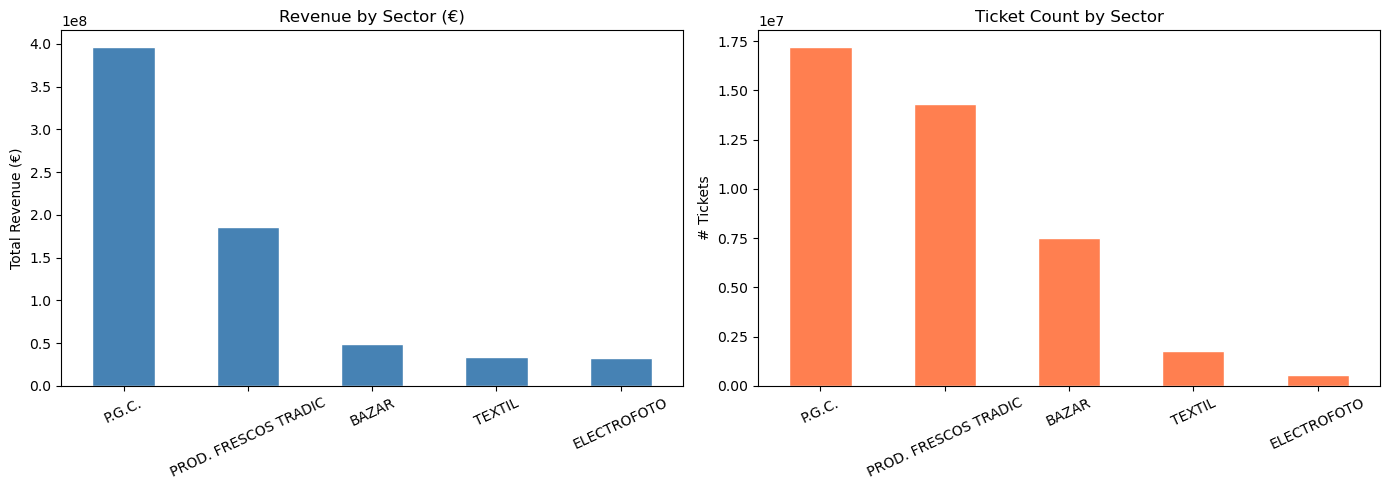

                        n_lines  n_tickets     total_rev  rev_share_pct
desc_sector                                                            
P.G.C.                113323710   17185944  3.959320e+08           56.8
PROD. FRESCOS TRADIC   60699024   14310308  1.859291e+08           26.7
BAZAR                  12012099    7496786  4.871528e+07            7.0
TEXTIL                  3708105    1794869  3.391014e+07            4.9
ELECTROFOTO              619581     536090  3.245429e+07            4.7


: 

In [ ]:
# ── 1. Revenue & transaction volume by sector ─────────────────────────────────
sector_agg = (
    df_combined
    .drop_nulls("desc_sector")
    .group_by("desc_sector")
    .agg([
        pl.len().alias("n_lines"),
        pl.col("ticket").n_unique().alias("n_tickets"),
        pl.col("importe").sum().alias("total_rev"),
        pl.col("importe").mean().alias("avg_importe"),
    ])
    .sort("total_rev", descending=True)
    .collect()
    .to_pandas()
    .set_index("desc_sector")
)
sector_agg["rev_share_pct"] = (sector_agg["total_rev"] / sector_agg["total_rev"].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sector_agg["total_rev"].plot.bar(ax=axes[0], color="steelblue", edgecolor="white",
    title="Revenue by Sector (€)")
axes[0].set_xlabel(""); axes[0].set_ylabel("Total Revenue (€)")
axes[0].tick_params(axis="x", rotation=25)
sector_agg["n_tickets"].plot.bar(ax=axes[1], color="coral", edgecolor="white",
    title="Ticket Count by Sector")
axes[1].set_xlabel(""); axes[1].set_ylabel("# Tickets")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_sector_revenue.png", dpi=120)
plt.show()
print(sector_agg[["n_lines", "n_tickets", "total_rev", "rev_share_pct"]].to_string())

### 4.2 Product Revenue Concentration (Pareto)

Retail purchase data is inherently Pareto-distributed: a small fraction of products drives the majority of revenue and, more importantly, the majority of co-purchase observations. This matters directly for Word2Vec — products that appear in very few baskets produce unreliable embeddings because there is not enough co-occurrence context to learn a meaningful vector.

The Pareto curve tells us how steep this concentration is and at roughly what product rank the embedding signal becomes too thin. This informs the `W2V_MIN_COUNT` threshold in `config.py`.

In [ ]:
# ── 2. Product concentration — Pareto curve ────────────────────────────────────
# high concentration → embeddings on top products will capture most signal
prod_rev = (
    df_combined
    .drop_nulls("desc_larga_articulo")
    .group_by(["idarticu", "desc_larga_articulo"])
    .agg(pl.col("importe").sum().alias("importe"))
    .sort("importe", descending=True)
    .collect()
    .to_pandas()
)
prod_rev["cumulative_rev_pct"] = (prod_rev["importe"].cumsum() / prod_rev["importe"].sum() * 100)
prod_rev["product_rank"] = range(1, len(prod_rev) + 1)

top_50_pct = prod_rev[prod_rev["cumulative_rev_pct"] <= 50].shape[0]
top_80_pct = prod_rev[prod_rev["cumulative_rev_pct"] <= 80].shape[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(prod_rev["product_rank"], prod_rev["cumulative_rev_pct"],
             color="steelblue", lw=1.5)
for threshold, n_prod in [(50, top_50_pct), (80, top_80_pct)]:
    axes[0].axhline(threshold, color="red", linestyle="--", lw=0.8, alpha=0.7)
    axes[0].axvline(n_prod, color="red", linestyle="--", lw=0.8, alpha=0.7)
    axes[0].text(n_prod + 50, threshold - 4, f"{n_prod:,} products → {threshold}% rev",
                 fontsize=8, color="red")
axes[0].set_xlabel("Product rank (by revenue)")
axes[0].set_ylabel("Cumulative revenue %")
axes[0].set_title("Product Revenue Concentration (Pareto)")
axes[0].set_xlim(0, min(len(prod_rev), 5000))
top20 = prod_rev.head(20).set_index("desc_larga_articulo")["importe"]
top20.plot.barh(ax=axes[1], color="coral", edgecolor="white",
                title="Top 20 Products by Revenue")
axes[1].set_xlabel("Revenue (€)"); axes[1].invert_yaxis()
axes[1].tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_product_concentration.png", dpi=120)
plt.show()
print(f"Products driving 50% of revenue  : {top_50_pct:,}")
print(f"Products driving 80% of revenue  : {top_80_pct:,}")
print(f"Total unique products in dataset : {len(prod_rev):,}")

### 4.3 Customer Behavioural KPI Distributions

These five KPIs — visit frequency, average basket size, total 6-month spend, promotional purchase rate, and product variety — are the axes along which customer tribes will ultimately differ. For clustering to work, each axis must show **genuine spread** across the customer population. A KPI where almost all customers look the same provides no discriminating power.

We measure spread using the **coefficient of variation** (CV = σ/μ). CV > 0.5 signals meaningful variance. The distributions also reveal skew and outliers, which inform how we should normalise features before UMAP reduction.

All metrics are computed over all 1.48M customers — no sampling.

In [ ]:
# ── 3. Per-customer KPI distributions (all 1.48M customers) ───────────────────
# basket-level agg in Polars, then roll up to customer — never materialises raw rows
basket_lf = (
    df_combined
    .group_by(["cliente", "ticket"])
    .agg([
        pl.len().alias("n_items"),
        pl.col("importe").sum().alias("total_spend"),
        (pl.col("idpromoc") == "Promo").sum().cast(pl.Float64).alias("promo_items"),
    ])
    .with_columns((pl.col("promo_items") / pl.col("n_items")).alias("promo_rate"))
)

cust_lf = basket_lf.group_by("cliente").agg([
    pl.len().alias("visit_count"),
    pl.col("total_spend").mean().alias("avg_basket_size"),
    pl.col("total_spend").sum().alias("total_spend_6m"),
    pl.col("promo_rate").mean().alias("avg_promo_rate"),
])

diversity_lf = df_combined.group_by("cliente").agg(
    pl.col("idarticu").n_unique().alias("unique_products")
)

cust_stats = cust_lf.join(diversity_lf, on="cliente").collect().to_pandas()

print(f"Customer KPI summary (n={len(cust_stats):,}):")
print(cust_stats[["visit_count","avg_basket_size","total_spend_6m","avg_promo_rate","unique_products"]]
      .describe().round(2).to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cust_stats["visit_count"].clip(upper=50).plot.hist(
    bins=40, ax=axes[0,0], color="steelblue", edgecolor="white",
    title="Visits per Customer (6 months)")
axes[0,0].set_xlabel("# visits")
cust_stats["avg_basket_size"].clip(upper=100).plot.hist(
    bins=40, ax=axes[0,1], color="coral", edgecolor="white",
    title="Avg Basket Size € (clipped at 100)")
axes[0,1].set_xlabel("€")
cust_stats["total_spend_6m"].clip(upper=2000).plot.hist(
    bins=50, ax=axes[0,2], color="mediumseagreen", edgecolor="white",
    title="Total 6-Month Spend € (clipped at 2,000)")
axes[0,2].set_xlabel("€")
cust_stats["avg_promo_rate"].plot.hist(
    bins=30, ax=axes[1,0], color="mediumpurple", edgecolor="white",
    title="Avg Promotional Purchase Rate")
axes[1,0].set_xlabel("Promo rate (0=never, 1=always promo)")
cust_stats["unique_products"].clip(upper=200).plot.hist(
    bins=40, ax=axes[1,1], color="darkorange", edgecolor="white",
    title="Unique Products per Customer (clipped at 200)")
axes[1,1].set_xlabel("# unique products")
s = cust_stats.sample(min(5000, len(cust_stats)), random_state=42)
sc = axes[1,2].scatter(s["visit_count"].clip(upper=50),
                        s["avg_basket_size"].clip(upper=150),
                        c=s["avg_promo_rate"], cmap="RdYlGn_r",
                        s=4, alpha=0.4)
plt.colorbar(sc, ax=axes[1,2], label="Promo rate")
axes[1,2].set_xlabel("Visit count"); axes[1,2].set_ylabel("Avg basket €")
axes[1,2].set_title("Visits vs Basket (colour = promo rate)")
plt.suptitle("Customer Behavioural KPI Distributions — All 1.48M Customers",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_customer_kpis.png", dpi=120)
plt.show()

### 4.4 Temporal Patterns & Store Distribution

Understanding how transaction volume varies by month, day of week, and store serves two purposes. First, it confirms **data completeness** — no missing months, no anomalous volume dips that might indicate an export gap. Second, it reveals the shopping rhythms the pipeline must account for. A customer who shops heavily in January but goes quiet in June should not look behaviourally identical to one who visits consistently throughout — Phase 2 uses time-decay weighting precisely to preserve this distinction.

Store distribution also matters: if one store dominates (store 7 accounts for 68% of volume), its customers' purchase context will heavily shape the embedding space.

In [ ]:
# ── 4. Temporal patterns + store distribution ──────────────────────────────────
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

monthly = (
    df_combined
    .with_columns(pl.col("fecha").dt.strftime("%Y-%m").alias("month"))
    .group_by("month")
    .agg(pl.col("ticket").n_unique().alias("n_tickets"))
    .sort("month")
    .collect().to_pandas().set_index("month")
)
dow = (
    df_combined
    .with_columns(pl.col("fecha").dt.strftime("%A").alias("day_of_week"))
    .group_by("day_of_week")
    .agg(pl.col("ticket").n_unique().alias("n_tickets"))
    .collect().to_pandas()
    .set_index("day_of_week").reindex(dow_order)
)
store_dist = (
    df_combined
    .group_by("idempres")
    .agg([
        pl.len().alias("n_lines"),
        pl.col("importe").sum().alias("total_rev"),
    ])
    .sort("idempres")
    .collect().to_pandas().set_index("idempres")
)
store_dist["rev_share_pct"] = (store_dist["total_rev"] / store_dist["total_rev"].sum() * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
monthly.plot.bar(ax=axes[0], color="steelblue", edgecolor="white",
    title="Unique Tickets per Month")
axes[0].set_xlabel(""); axes[0].set_ylabel("# tickets")
axes[0].tick_params(axis="x", rotation=15)
dow.plot.bar(ax=axes[1], color="coral", edgecolor="white",
    title="Tickets by Day of Week")
axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=25)
store_dist["n_lines"].plot.bar(ax=axes[2], color="mediumseagreen", edgecolor="white",
    title="Transaction Lines per Store")
axes[2].set_xlabel("Store ID"); axes[2].set_ylabel("# lines")
axes[2].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_temporal_store.png", dpi=120)
plt.show()

print("Store revenue breakdown:")
print(store_dist[["n_lines","total_rev","rev_share_pct"]].to_string())

### 4.5 Promotional Sensitivity Analysis

The `idpromoc` field flags whether each line item was purchased on promotion. This is one of the most commercially powerful behavioural axes in the dataset — it separates **brand loyalists** (who buy regardless of price) from **promo surfers** (who systematically wait for discounts). These two archetypes are worth very different things to Carrefour and require completely different commercial strategies.

This analysis quantifies the promotional rate at both sector level (which categories attract promotion-driven shopping?) and customer level (what fraction of customers are promo-driven vs. price-insensitive?). Strong signal here confirms that weaving a promo-sensitivity score into Phase 2 customer vectors — rather than discarding `idpromoc` — will produce more commercially meaningful tribes.

In [ ]:
# ── 5. Promotional sensitivity — sector and customer level ────────────────────
# key differentiating axis: promo surfers vs brand loyalists
promo_sector = (
    df_combined
    .drop_nulls("desc_sector")
    .group_by("desc_sector")
    .agg([
        pl.len().alias("total"),
        (pl.col("idpromoc") == "Promo").sum().alias("promo"),
    ])
    .with_columns((pl.col("promo").cast(pl.Float64) / pl.col("total") * 100).alias("promo_rate_pct"))
    .sort("promo_rate_pct", descending=True)
    .collect()
    .to_pandas()
    .set_index("desc_sector")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
promo_sector["promo_rate_pct"].plot.bar(ax=axes[0], color="mediumpurple", edgecolor="white",
    title="Promotional Line Rate by Sector (%)")
axes[0].set_xlabel(""); axes[0].set_ylabel("% lines on promotion")
axes[0].tick_params(axis="x", rotation=25)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=8)
cust_stats["avg_promo_rate"].plot.hist(
    bins=30, ax=axes[1], color="darkorange", edgecolor="white",
    title="Distribution of Customer Promotional Rate")
axes[1].axvline(cust_stats["avg_promo_rate"].mean(), color="red", lw=1.5,
    label=f"mean = {cust_stats['avg_promo_rate'].mean():.2f}")
axes[1].legend()
axes[1].set_xlabel("Avg promo rate (0 = never, 1 = always buy on promo)")
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_promo_analysis.png", dpi=120)
plt.show()

print(f"Overall promo rate in dataset    : {overall_promo_rate*100:.1f}%")
print(f"Customers with 0% promo          : {(cust_stats['avg_promo_rate'] == 0).mean()*100:.1f}%")
print(f"Customers with >50% promo        : {(cust_stats['avg_promo_rate'] > 0.5).mean()*100:.1f}%")

### 4.6 Customer Revenue Concentration (CLV Preview)

A Lorenz curve of customer spend quantifies how unequally revenue is distributed across the customer base. If — as in most retail datasets — the top 10–20% of customers account for a disproportionate share of revenue, then identifying and protecting those tribes becomes a direct commercial priority, not an academic exercise.

This analysis provides the jury with the most tangible business hook: it directly answers "so what does Carrefour do with this?" before we have even run the clustering. High-value, high-stability tribes identified in Phase 4 map back to the revenue concentration pattern revealed here.

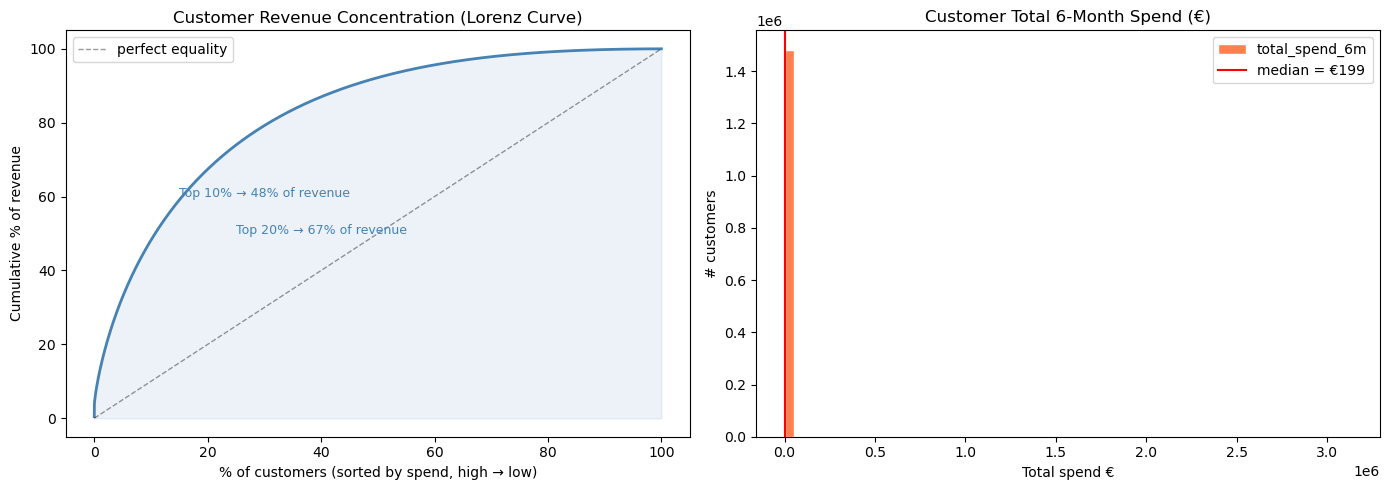

Top 10% of customers drive 48% of revenue
Top 20% of customers drive 67% of revenue
Median 6-month spend: €199


In [ ]:
# ── 6. Revenue concentration by customer (CLV preview) ───────────────────────
# If revenue is highly concentrated in a small % of customers, those are high-value tribes.
cust_stats_sorted = cust_stats.sort_values("total_spend_6m", ascending=False).reset_index(drop=True)
cust_stats_sorted["cumulative_rev_pct"] = (
    cust_stats_sorted["total_spend_6m"].cumsum() / cust_stats_sorted["total_spend_6m"].sum() * 100
)
cust_stats_sorted["customer_pct"] = (cust_stats_sorted.index + 1) / len(cust_stats_sorted) * 100

top10_share = cust_stats_sorted[cust_stats_sorted["customer_pct"] <= 10]["total_spend_6m"].sum() \
              / cust_stats_sorted["total_spend_6m"].sum() * 100
top20_share = cust_stats_sorted[cust_stats_sorted["customer_pct"] <= 20]["total_spend_6m"].sum() \
              / cust_stats_sorted["total_spend_6m"].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cust_stats_sorted["customer_pct"], cust_stats_sorted["cumulative_rev_pct"],
             color="steelblue", lw=2)
axes[0].plot([0, 100], [0, 100], "k--", lw=1, alpha=0.4, label="perfect equality")
axes[0].fill_between(cust_stats_sorted["customer_pct"], cust_stats_sorted["cumulative_rev_pct"],
                     alpha=0.1, color="steelblue")
axes[0].set_xlabel("% of customers (sorted by spend, high → low)")
axes[0].set_ylabel("Cumulative % of revenue")
axes[0].set_title("Customer Revenue Concentration (Lorenz Curve)")
axes[0].text(15, 60, f"Top 10% → {top10_share:.0f}% of revenue", fontsize=9, color="steelblue")
axes[0].text(25, 50, f"Top 20% → {top20_share:.0f}% of revenue", fontsize=9, color="steelblue")
axes[0].legend()

# spend distribution log scale
cust_stats["total_spend_6m"].plot.hist(bins=60, ax=axes[1], color="coral",
    edgecolor="white", title="Customer Total 6-Month Spend (€)")
axes[1].set_xlabel("Total spend €"); axes[1].set_ylabel("# customers")
axes[1].axvline(cust_stats["total_spend_6m"].median(), color="red", lw=1.5,
    label=f"median = €{cust_stats['total_spend_6m'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS / "eda_revenue_concentration.png", dpi=120)
plt.show()
print(f"Top 10% of customers drive {top10_share:.0f}% of revenue")
print(f"Top 20% of customers drive {top20_share:.0f}% of revenue")
print(f"Median 6-month spend: €{cust_stats['total_spend_6m'].median():.0f}")

### 4.7 Behavioural KPI Correlation Matrix

Before building customer vectors for clustering, it is important to understand which KPIs co-vary and which are genuinely independent. Highly correlated features carry redundant information: if visit frequency and total spend are almost perfectly correlated, including both in the feature space effectively double-weights that single axis, skewing the distance metric.

The correlation heatmap reveals the underlying structure of the behavioural space. Independent KPIs (low correlation with all others) are the most valuable for discrimination — they add orthogonal signal. This analysis informs which features to prioritise and whether any should be dropped or combined before Phase 3.

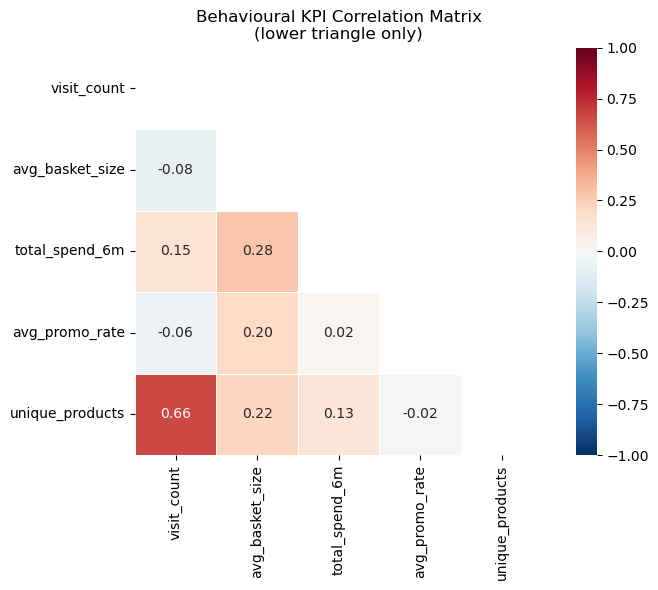

Interpretation:
  visit_count × unique_products : r=0.66  (positive correlation)


In [ ]:
# ── 7. Customer behavioural correlation matrix ────────────────────────────────
# Reveals which KPIs co-vary — important for understanding what the
# embedding + clustering will separate vs. conflate.

corr_cols = ["visit_count", "avg_basket_size", "total_spend_6m",
             "avg_promo_rate", "unique_products"]
corr = cust_stats[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, mask=mask,
            linewidths=0.5, square=True)
ax.set_title("Behavioural KPI Correlation Matrix\n(lower triangle only)")
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_correlation_matrix.png", dpi=120)
plt.show()

print("Interpretation:")
for i, c1 in enumerate(corr_cols):
    for c2 in corr_cols[i+1:]:
        r = corr.loc[c1, c2]
        if abs(r) > 0.4:
            direction = "positive" if r > 0 else "negative"
            print(f"  {c1} × {c2} : r={r:.2f}  ({direction} correlation)")

### 4.8 Segmentation Viability Assessment

The final EDA step is a formal go/no-go signal. We compute the **coefficient of variation** (CV = σ/μ) for each KPI across all customers. CV > 0.5 indicates that customers genuinely differ on that axis — enough spread to expect separable clusters in the UMAP/HDBSCAN pipeline. CV < 0.3 would suggest the dimension is too uniform to contribute to tribe discovery.

This transforms EDA from passive observation into a data-driven decision: if the KPIs pass, we proceed with confidence. If any fail, we know to investigate before investing in training.

In [ ]:
# ── 8. Segmentation viability summary ────────────────────────────────────────
# coefficient of variation (CV = std/mean): CV > 0.5 is promising for clustering

print("=" * 65)
print("  SEGMENTATION VIABILITY ASSESSMENT")
print("=" * 65)
print()

kpi_labels = {
    "visit_count"    : "Visits per customer (6m)",
    "avg_basket_size": "Avg basket size €",
    "total_spend_6m" : "Total spend € (6m)",
    "avg_promo_rate" : "Promo sensitivity rate",
    "unique_products": "Product variety (# unique SKUs)",
}

for col, label in kpi_labels.items():
    vals   = cust_stats[col]
    cv     = vals.std() / vals.mean()
    signal = "STRONG" if cv > 0.7 else ("MODERATE" if cv > 0.4 else "WEAK")
    print(f"  {label:<40} CV={cv:.2f}  [{signal}]")

print()
print(f"  Unique customers in dataset     : {len(cust_stats):,}")
print(f"  Unique products in dataset      : {n_products:,}")
print(f"  Overall promo rate              : {overall_promo_rate*100:.1f}%")
print()
print("Conclusion:")
high_cv = sum(
    1 for col in kpi_labels
    if cust_stats[col].std() / cust_stats[col].mean() > 0.5
)
print(f"  {high_cv}/{len(kpi_labels)} KPIs show CV > 0.5 — {'sufficient' if high_cv >= 3 else 'marginal'} "
      "behavioural variance for clustering.")
print("  The data supports discovery of distinct purchase-behaviour tribes.")
print("=" * 65)

  SEGMENTATION VIABILITY ASSESSMENT

  Visits per customer (6m)                 CV=1.46  [STRONG]
  Avg basket size €                        CV=1.23  [STRONG]
  Total spend € (6m)                       CV=9.92  [STRONG]
  Promo sensitivity rate                   CV=0.72  [STRONG]
  Product variety (# unique SKUs)          CV=1.21  [STRONG]

  Unique customers in dataset     : 1,482,715
  Unique products in dataset      : 117,621
  Overall promo rate              : 22.1%

Conclusion:
  5/5 KPIs show CV > 0.5 — sufficient behavioural variance for clustering.
  The data supports discovery of distinct purchase-behaviour tribes.
